In [1]:
import warnings
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import RobustScaler
from pybaseball import statcast, batting_stats, playerid_reverse_lookup

# --- Pull Statcast in monthly chunks ---
date_ranges = [
    ("2023-04-01", "2023-04-30"),
    ("2023-05-01", "2023-05-31"),
    ("2023-06-01", "2023-06-30"),
    ("2023-07-01", "2023-07-31"),
    ("2023-08-01", "2023-08-31"),
    ("2023-09-01", "2023-09-30"),
]

chunks = []
for start, end in date_ranges:
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FutureWarning)
        df = statcast(start_dt=start, end_dt=end)
    chunks.append(df)

statcast_df = pd.concat(chunks, ignore_index=True)

# --- Pull batter xwOBA from FanGraphs ---
fg_batters = batting_stats(2023, qual=50)

This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:11<00:00,  2.64it/s]


This is a large query, it may take a moment to complete


100%|██████████| 31/31 [00:11<00:00,  2.75it/s]


This is a large query, it may take a moment to complete


...

100%|██████████| 31/31 [00:13<00:00,  2.21it/s]


This is a large query, it may take a moment to complete


100%|██████████| 31/31 [00:09<00:00,  3.11it/s]


This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:11<00:00,  2.53it/s]


In [2]:
IDmlbam = statcast_df.batter.unique()
lookup_df = playerid_reverse_lookup(IDmlbam)[['key_mlbam', 'key_fangraphs']]
# rename for clarity
lookup_df = lookup_df.rename(columns={
    'key_mlbam': 'batter',
    'key_fangraphs': 'IDfg',
    })

trn_df = statcast_df.join(
    lookup_df.set_index('batter'), 
    on='batter',
    how = 'left'
).join(
    fg_batters.set_index('IDfg')['xwOBA'], 
    on='IDfg',
    how='left'
)
league_avg_xwoba = fg_batters['xwOBA'].mean()
trn_df['xwOBA'] = trn_df['xwOBA'].fillna(league_avg_xwoba)

Gathering player lookup table. This may take a moment.


In [3]:
STUFF_COLS    = ['release_speed', 'pfx_x', 'pfx_z', 'release_spin_rate', 'release_extension']
COMMAND_COLS  = ['plate_x', 'plate_z', 'zone']
PITCH_TYPE_COL = 'pitch_type'
SEQUENCING_COLS = ['prev_pitch_type', 'pitch_number']  # pitch_number is pitch count within PA
BATTER_COL    = 'xwOBA'
TARGET        = 'delta_run_exp'

FEATURES  = STUFF_COLS + COMMAND_COLS + ['pitch_type_enc', 'prev_pitch_type_enc', 'pitch_number', 'xwOBA']
CONT_COLS = [c for c in FEATURES if c not in ['pitch_type_enc', 'prev_pitch_type_enc']]

trn_df = trn_df.sort_values(['game_pk', 'at_bat_number', 'pitch_number'])
trn_df['prev_pitch_type'] = trn_df.groupby(['game_pk', 'at_bat_number'])['pitch_type'].shift(1)
trn_df['prev_pitch_type'] = trn_df['prev_pitch_type'].fillna('START')

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# fit on combined to ensure consistent encoding
all_pitch_types = pd.concat([trn_df['pitch_type'], trn_df['prev_pitch_type']]).unique()
le.fit(all_pitch_types)

trn_df['pitch_type_enc'] = le.transform(trn_df['pitch_type'])
trn_df['prev_pitch_type_enc'] = le.transform(trn_df['prev_pitch_type'])

In [5]:
trn_df[FEATURES + [TARGET]].isnull().sum()

release_speed          2810
pfx_x                  2813
pfx_z                  2813
release_spin_rate      6768
release_extension      3787
plate_x                2974
plate_z                2974
zone                   2974
pitch_type_enc            0
prev_pitch_type_enc       0
pitch_number              0
xwOBA                     0
delta_run_exp          2711
dtype: int64

In [6]:
trn_df[FEATURES].isnull().sum() / len(trn_df)

release_speed          0.003956
pfx_x                  0.003960
pfx_z                  0.003960
release_spin_rate      0.009528
release_extension      0.005332
plate_x                0.004187
plate_z                0.004187
zone                   0.004187
pitch_type_enc         0.000000
prev_pitch_type_enc    0.000000
pitch_number           0.000000
xwOBA                  0.000000
dtype: float64

In [7]:
trn_df = trn_df.dropna(subset=FEATURES + [TARGET])
print(f"Rows remaining: {len(trn_df):,}")

Rows remaining: 703,145


In [8]:
trn_df['game_date'] = pd.to_datetime(trn_df['game_date'])

train = trn_df[trn_df['game_date'] < '2023-08-01']
test  = trn_df[trn_df['game_date'] >= '2023-08-01']

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 460,825 | Test: 242,320


<Axes: >

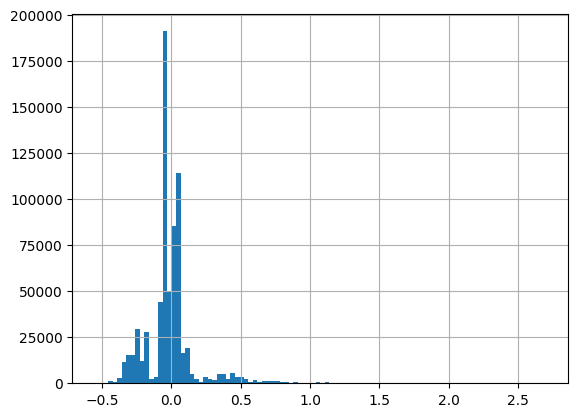

In [9]:
import matplotlib.pyplot as plt
trn_df[TARGET].hist(bins=100)

In [10]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [11]:
import torch
import torch.nn as nn

class PitchValueNet(nn.Module):
    def __init__(self, n_pitch_types, emb_dim, n_continuous):
        super().__init__()
        
        # two separate embedding tables
        self.emb_current  = nn.Embedding(n_pitch_types, emb_dim)
        self.emb_previous = nn.Embedding(n_pitch_types, emb_dim)
        
        # MLP input dim = emb_dim + emb_dim + n_continuous
        mlp_input_dim = emb_dim * 2 + n_continuous
        
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x_cont, x_pitch_type, x_prev_pitch_type):
        emb1 = self.emb_current(x_pitch_type)
        emb2 = self.emb_previous(x_prev_pitch_type)
   
        x = torch.cat([emb1, emb2, x_cont], dim=1)
        return self.mlp(x)

In [12]:
scaler = RobustScaler()
X_cont_train_scaled = scaler.fit_transform(X_train[CONT_COLS])
X_cont_test_scaled  = scaler.transform(X_test[CONT_COLS])

X_cont_train   = torch.tensor(X_cont_train_scaled, dtype=torch.float32)
X_cont_test    = torch.tensor(X_cont_test_scaled,  dtype=torch.float32)
X_pitch_train  = torch.tensor(X_train['pitch_type_enc'].values, dtype=torch.long)
X_pitch_test   = torch.tensor(X_test['pitch_type_enc'].values,  dtype=torch.long)
X_prev_train   = torch.tensor(X_train['prev_pitch_type_enc'].values, dtype=torch.long)
X_prev_test    = torch.tensor(X_test['prev_pitch_type_enc'].values,  dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values,  dtype=torch.float32)

dataloader = DataLoader(
    TensorDataset(X_cont_train, X_pitch_train, X_prev_train, y_train_tensor),
    batch_size=512, shuffle=True,
)
test_dataloader = DataLoader(
    TensorDataset(X_cont_test, X_pitch_test, X_prev_test, y_test_tensor),
    batch_size=512, shuffle=False,
)

n_pitch_types = len(le.classes_)
model = PitchValueNet(n_pitch_types=n_pitch_types, emb_dim=9, n_continuous=len(CONT_COLS)).to(device)
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_cont_b, X_pitch_b, X_prev_b, y_b in loader:
        X_cont_b, X_pitch_b, X_prev_b, y_b = (
            X_cont_b.to(device), X_pitch_b.to(device), X_prev_b.to(device), y_b.to(device)
        )
        optimizer.zero_grad()
        loss = criterion(model(X_cont_b, X_pitch_b, X_prev_b).squeeze(), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
    return total_loss / len(loader.dataset)


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_cont_b, X_pitch_b, X_prev_b, y_b in loader:
            X_cont_b, X_pitch_b, X_prev_b, y_b = (
                X_cont_b.to(device), X_pitch_b.to(device), X_prev_b.to(device), y_b.to(device)
            )
            total_loss += criterion(model(X_cont_b, X_pitch_b, X_prev_b).squeeze(), y_b).item() * len(y_b)
    return total_loss / len(loader.dataset)


for epoch in range(10):
    train_loss = train_one_epoch(model, dataloader,      optimizer, criterion, device)
    val_loss   = eval_one_epoch( model, test_dataloader, criterion, device)
    print(f"Epoch {epoch+1:2d}: train={train_loss:.4f}  val={val_loss:.4f}")

Epoch  1: train=0.0520  val=0.0530
Epoch  2: train=0.0513  val=0.0524
Epoch  3: train=0.0512  val=0.0525
Epoch  4: train=0.0511  val=0.0522
Epoch  5: train=0.0511  val=0.0522
Epoch  6: train=0.0510  val=0.0522
Epoch  7: train=0.0510  val=0.0522
Epoch  8: train=0.0510  val=0.0524
Epoch  9: train=0.0510  val=0.0521
Epoch 10: train=0.0509  val=0.0521


In [17]:
from scipy.stats import spearmanr
import pybaseball

# Step 1: get pitch-level predictions on test set
model.eval()
with torch.no_grad():
    test_preds = model(X_cont_test.to(device), X_pitch_test.to(device), X_prev_test.to(device)).squeeze().cpu().numpy()

# Step 2: attach predictions back to test dataframe
test_df = test.copy()
test_df['pred_xrv'] = test_preds

# Step 3: aggregate to pitcher level
# YOUR TASK: aggregate pred_xrv to pitcher level
# hint: lower mean xRV = better pitcher (fewer runs allowed)
# what column in statcast_df identifies the pitcher?
pitcher_xrv = test_df[['pitcher', 'pred_xrv']].groupby('pitcher').mean().reset_index()

# Step 4: pull Stuff+ from FanGraphs
# hint: pybaseball.pitching_stats() — what arguments do you need?
stuff_plus = pybaseball.pitching_stats(2023, qual=50) 

# Step 5: merge and correlate
# YOUR TASK: merge pitcher_xrv with stuff_plus and compute spearmanr

In [18]:
test_df[['pitcher', 'pred_xrv']].groupby('pitcher').mean().reset_index().sort_values('pred_xrv', ascending=False)

,pitcher,pred_xrv
514,670097,0.035847
430,664874,0.031978
127,595978,0.030076
10,455117,0.028274
393,663558,0.026322
...,...,...
232,623474,-0.018518
377,661403,-0.020804
642,689147,-0.024197
111,592779,-0.024404


In [19]:
IDmlbam = pitcher_xrv['pitcher'].unique()
lookup_df = playerid_reverse_lookup(IDmlbam)[['key_mlbam', 'key_fangraphs']]
lookup_pitcher = lookup_df.rename(columns={'key_fangraphs': 'IDfg', 'key_mlbam': 'pitcher'})

stuff_plus_subset = stuff_plus[['IDfg', 'Stuff+']]
merged = pitcher_xrv.merge(lookup_pitcher, on='pitcher', how='left').merge(stuff_plus_subset, on='IDfg', how='left')

In [20]:
from scipy.stats import spearmanr

# drop any pitchers who didn't match to FanGraphs
merged_clean = merged.dropna(subset=['Stuff+'])

corr, pval = spearmanr(merged_clean['pred_xrv'], merged_clean['Stuff+'])
print(f"Spearman r = {corr:.3f}, p-value = {pval:.4f}")

Spearman r = -0.477, p-value = 0.0000


In [21]:
# impute location and sequencing columns with 0 (post-scaling mean)
LOCATION_COLS = ['plate_x', 'plate_z', 'zone']
SEQUENCING_COLS = ['pitch_number']  # prev_pitch_type handled separately

cont_col_indices = {col: i for i, col in enumerate(CONT_COLS)}

X_cont_test_ablated = X_cont_test.clone()

# zero out location cols
for col in LOCATION_COLS + SEQUENCING_COLS:
    idx = cont_col_indices[col]
    X_cont_test_ablated[:, idx] = 0.0

# for prev_pitch_type — what value would you use to represent "no sequencing info"?
start_idx = le.transform(['START'])[0]
X_prev_test_ablated = torch.full_like(X_prev_test, start_idx)

In [22]:
model.eval()
with torch.no_grad():
    test_preds_ablated = model(
        X_cont_test_ablated.to(device), 
        X_pitch_test.to(device),          # pitch type unchanged
        X_prev_test_ablated.to(device)    # sequencing neutralized
    ).squeeze().cpu().numpy()

test_df['pred_xrv_ablated'] = test_preds_ablated

pitcher_xrv_ablated = test_df.groupby('pitcher')['pred_xrv_ablated'].mean().reset_index()

merged_ablated = pitcher_xrv_ablated.merge(lookup_pitcher, on='pitcher', how='left').merge(stuff_plus_subset, on='IDfg', how='left').dropna(subset=['Stuff+'])

corr_ablated, pval_ablated = spearmanr(merged_ablated['pred_xrv_ablated'], merged_ablated['Stuff+'])
print(f"Ablated Spearman r = {corr_ablated:.3f}, p-value = {pval_ablated:.4f}")

Ablated Spearman r = -0.413, p-value = 0.0000


In [23]:
# pull SIERA from FanGraphs — already in pitching_stats
siera_subset = stuff_plus[['IDfg', 'SIERA']]

# YOUR TASK:
# 1. merge pitcher_xrv (full model) with SIERA
merged_siera = pitcher_xrv.merge(lookup_pitcher, on='pitcher', how='left').merge(siera_subset, on='IDfg', how='left').dropna(subset=['SIERA'])
# 2. merge pitcher_xrv_ablated with SIERA  
merged_siera_ablated = pitcher_xrv_ablated.merge(lookup_pitcher, on='pitcher', how='left').merge(siera_subset, on='IDfg', how='left').dropna(subset=['SIERA'])
# 3. compute spearmanr for both
corr_siera, pval_siera = spearmanr(merged_siera['pred_xrv'], merged_siera['SIERA'])
corr_siera_ablated, pval_siera_ablated = spearmanr(merged_siera_ablated['pred_xrv_ablated'], merged_siera_ablated['SIERA'])
# 4. compare all four correlations in a summary table
print(f"Full Model vs SIERA: Spearman r = {corr_siera:.3f}, p-value = {pval_siera:.4f}")
print(f"Ablated Model vs SIERA: Spearman r = {corr_siera_ablated:.3f}, p-value = {pval_siera_ablated:.4f}")

Full Model vs SIERA: Spearman r = 0.431, p-value = 0.0000
Ablated Model vs SIERA: Spearman r = 0.245, p-value = 0.0000


# Stage 2: Exponential Decay

In [24]:
import numpy as np

# first get full season predictions
# YOUR TASK: generate pred_xrv for the full dataset (not just test)
# hint: you need to build tensors from trn_df the same way as before

trn_df['game_date'] = pd.to_datetime(trn_df['game_date'])

X_full = trn_df[FEATURES]
y_full = trn_df[TARGET]

X_cont_full_scaled  = scaler.transform(X_full[CONT_COLS])

X_cont_full    = torch.tensor(X_cont_full_scaled,  dtype=torch.float32, device=device)
X_pitch_full  = torch.tensor(X_full['pitch_type_enc'].values, dtype=torch.long, device=device)
X_prev_full   = torch.tensor(X_full['prev_pitch_type_enc'].values, dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    pred_xrv_full = model(X_cont_full, X_pitch_full, X_prev_full).squeeze().cpu().numpy()

trn_df['pred_xrv'] = pred_xrv_full

# then compute exponential decay weighted mean per pitcher as of a given date T
def pitcher_score(df, pitcher_id, as_of_date, lam=0.046):
    """
    df: full dataframe with pred_xrv and game_date
    returns: exponentially weighted mean xRV for pitcher as of date T
    """
    pitcher_df = df[df['pitcher'] == pitcher_id].copy()
    pitcher_df = pitcher_df[pitcher_df['game_date'] <= as_of_date]
    
    T = pd.Timestamp(as_of_date)
    
    pitcher_df['days_ago'] = (T - pitcher_df['game_date']).dt.days
    pitcher_df['weight']   = np.exp(-lam * pitcher_df['days_ago'])
    
    weighted_xrv = (pitcher_df['weight'] * pitcher_df['pred_xrv']).sum() / pitcher_df['weight'].sum()
    return weighted_xrv

In [25]:
def pitcher_leaderboard(df, as_of_date, min_pitches=100, lam=0.046):
    """
    Returns ranked dataframe of all pitchers as of a given date
    min_pitches: minimum pitch count to filter small samples
    """
    # filter to pitchers with enough pitches up to as_of_date
    eligible = (
        df[df['game_date'] <= as_of_date]
        .groupby('pitcher')['pred_xrv']
        .count()
        .reset_index()
        .rename(columns={'pred_xrv': 'pitch_count'})
    )
    eligible = eligible[eligible['pitch_count'] >= min_pitches]
    
    # YOUR TASK: compute pitcher_score for each eligible pitcher
    # then sort — which direction? ascending or descending?
    eligible['weighted_xrv'] = eligible['pitcher'].apply(lambda pid: pitcher_score(df, pid, as_of_date, lam))
    
    return eligible.sort_values('weighted_xrv', ascending=True)

In [26]:
leaderboard = pitcher_leaderboard(trn_df, as_of_date='2023-08-01')

top5_ids = leaderboard.head(5)['pitcher'].values
playerid_reverse_lookup(top5_ids)[['key_mlbam', 'name_first', 'name_last']]

,key_mlbam,name_first,name_last
0,623474,jimmy,herget
1,594798,jacob,degrom
2,594580,sam,moll
3,547973,aroldis,chapman
4,661403,emmanuel,clase


In [27]:
# classify SP vs RP based on median pitches per appearance
pitcher_appearance = (
    trn_df.groupby(['pitcher', 'game_pk'])['pitch_number']
    .count()
    .reset_index()
    .rename(columns={'pitch_number': 'pitches_in_game'})
)

pitcher_type = (
    pitcher_appearance.groupby('pitcher')['pitches_in_game']
    .median()
    .reset_index()
    .rename(columns={'pitches_in_game': 'median_pitches'})
)

pitcher_type['role'] = pitcher_type['median_pitches'].apply(
    lambda x: 'SP' if x >= 50 else 'RP'
)

# merge back to trn_df
trn_df = trn_df.merge(pitcher_type[['pitcher', 'role']], on='pitcher', how='left')

In [28]:
def pitcher_leaderboard(df, as_of_date, role='SP', min_pitches=100, lam=0.046):
    eligible = (
        df[(df['game_date'] <= as_of_date) & (df['role'] == role)]
        .groupby('pitcher')['pred_xrv']
        .count()
        .reset_index()
        .rename(columns={'pred_xrv': 'pitch_count'})
    )
    eligible = eligible[eligible['pitch_count'] >= min_pitches]
    
    # YOUR TASK: compute pitcher_score for each eligible pitcher
    # then sort — which direction? ascending or descending?
    eligible['weighted_xrv'] = eligible['pitcher'].apply(lambda pid: pitcher_score(df, pid, as_of_date, lam))
    
    return eligible.sort_values('weighted_xrv', ascending=True)

In [29]:
leaderboard = pitcher_leaderboard(trn_df, as_of_date='2023-08-01', role = 'SP')

top10_ids = leaderboard.head(10)['pitcher'].values
playerid_reverse_lookup(top10_ids)[['key_mlbam', 'name_first', 'name_last']]

,key_mlbam,name_first,name_last
0,669373,tarik,skubal
1,669203,corbin,burnes
2,656876,drew,rasmussen
3,694297,brandon,pfaadt
4,607192,tyler,glasnow
5,666159,matt,manning
6,594798,jacob,degrom
7,668933,graham,ashcraft
8,554430,zack,wheeler
9,605488,jeffrey,springs


In [30]:
leaderboard = pitcher_leaderboard(trn_df, as_of_date='2023-08-01', role = 'RP')

top10_ids = leaderboard.head(10)['pitcher'].values
playerid_reverse_lookup(top10_ids)[['key_mlbam', 'name_first', 'name_last']]

,key_mlbam,name_first,name_last
0,666619,gregory,santos
1,642585,félix,bautista
2,681806,andrew,wantz
3,592779,brock,stewart
4,623474,jimmy,herget
5,676534,calvin,faucher
6,594580,sam,moll
7,445276,kenley,jansen
8,547973,aroldis,chapman
9,661403,emmanuel,clase


In [31]:
import pandas as pd
import numpy as np

# generate weekly snapshots throughout the season
as_of_dates = pd.date_range(start='2023-04-01', end='2023-09-30', freq='W')

# YOUR TASK: for a given pitcher_id, compute weighted_xrv at each date
# and return a time series dataframe

def pitcher_trajectory(df, pitcher_id, dates, lam=0.046):
    records = []
    for date in dates:
        # filter to minimum pitch count before scoring
        pitch_count = len(df[(df['pitcher'] == pitcher_id) & 
                             (df['game_date'] <= date)])
        if pitch_count >= 100:
            score = pitcher_score(df, pitcher_id, date, lam)
            records.append({'date': date, 'weighted_xrv': score})
    
    return pd.DataFrame(records)

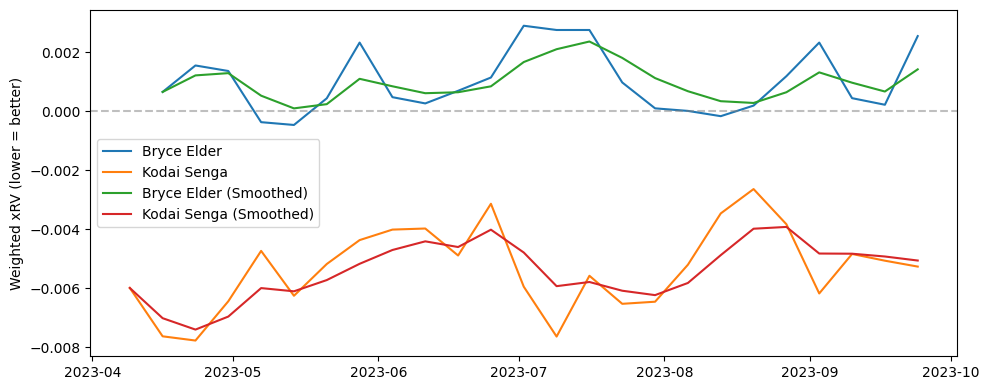

In [32]:
import matplotlib.pyplot as plt

# look up IDs
names = [('elder', 'bryce'), ('senga', 'kodai')]
# use playerid_lookup to get MLBAM IDs
from pybaseball import playerid_lookup

elder_id = playerid_lookup('elder', 'bryce')['key_mlbam'].values[0]
senga_id = playerid_lookup('senga', 'kodai')['key_mlbam'].values[0]

# compute trajectories
elder_traj = pitcher_trajectory(trn_df, elder_id, as_of_dates)
senga_traj = pitcher_trajectory(trn_df, senga_id, as_of_dates)

elder_traj['smoothed_xrv'] = elder_traj['weighted_xrv'].ewm(span=4).mean()
senga_traj['smoothed_xrv'] = senga_traj['weighted_xrv'].ewm(span=4).mean()

# plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(elder_traj['date'], elder_traj['weighted_xrv'], label='Bryce Elder')
ax.plot(senga_traj['date'], senga_traj['weighted_xrv'], label='Kodai Senga')
ax.plot(elder_traj['date'], elder_traj['smoothed_xrv'], label='Bryce Elder (Smoothed)')
ax.plot(senga_traj['date'], senga_traj['smoothed_xrv'], label='Kodai Senga (Smoothed)')
ax.axhline(0, linestyle='--', color='gray', alpha=0.5)
ax.set_ylabel('Weighted xRV (lower = better)')
ax.legend()
plt.tight_layout()
plt.show()

---
# Bayesian Neural Net

In [79]:
import torch
as_of_date = pd.Timestamp('2023-09-30')
lam = 0.046

appearance_df = (
    trn_df[trn_df['role'] == 'SP']
    .groupby(['pitcher', 'game_pk', 'game_date'])
    .agg(mean_xrv=('pred_xrv', 'mean'))
    .reset_index()
)

# YOUR TASK:
# 1. compute decay weight per appearance

decay_weight = np.exp(-lam * (as_of_date - appearance_df['game_date']).dt.days)  # weight of an appearance 30 days ago
weighted_xrv = (decay_weight * appearance_df['mean_xrv']).sum() / decay_weight.sum()

# 2. create pitcher_idx — contiguous integers from 0
#    hint: pd.Categorical or factorize
appearance_df = (
    trn_df[trn_df['role'] == 'SP']
    .groupby(['pitcher', 'game_pk'])
    .agg(mean_xrv=('pred_xrv', 'mean'))
    .reset_index()
)
appearance_df['pitcher_idx'] = pd.factorize(appearance_df['pitcher'])[0]
n_pitchers = appearance_df['pitcher_idx'].nunique()

obs_xrv     = torch.tensor(appearance_df['mean_xrv'].values, dtype=torch.float32)
pitcher_ids = torch.tensor(appearance_df['pitcher_idx'].values, dtype=torch.long)


In [80]:
import pyro
import pyro.distributions as dist

def model(pitcher_ids, appearance_xrv, n_pitchers):
    mu_league    = pyro.sample('mu_league',    dist.Normal(0, 0.01))
    sigma_league = pyro.sample('sigma_league', dist.HalfNormal(0.005))
    sigma_noise  = pyro.sample('sigma_noise',  dist.HalfNormal(0.005))
    
    with pyro.plate('pitchers', n_pitchers):
        z          = pyro.sample('z', dist.Normal(0, 1))
        mu_pitcher = mu_league + z * sigma_league
    
    with pyro.plate('appearances', len(appearance_xrv)):
        pyro.sample('obs', dist.Normal(
            mu_pitcher[pitcher_ids],
            sigma_noise
        ), obs=appearance_xrv)

In [82]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal
import pyro.optim as optim

from pyro.optim import ClippedAdam

# obs_weights = torch.tensor(
#     appearance_df['weight'].clip(lower=0.1).values, 
#     dtype=torch.float32
# )

pyro.clear_param_store()
guide  = AutoNormal(model)
svi    = SVI(model, guide, ClippedAdam({"lr": 0.001, "lrd": 0.999}), Trace_ELBO())

losses = []
for step in range(5000):
    loss = svi.step(pitcher_ids, obs_xrv, n_pitchers)
    losses.append(loss)
    if step % 200 == 0:
        print(f"Step {step}: ELBO = {-loss:.4f}")

Step 0: ELBO = -47382.8714
Step 200: ELBO = -32349.9836
Step 400: ELBO = -35553.1070
Step 600: ELBO = -12811.8067
Step 800: ELBO = -16609.9838
Step 1000: ELBO = -11837.0691
Step 1200: ELBO = -12431.5091
Step 1400: ELBO = -12977.1955
Step 1600: ELBO = -8259.0449
Step 1800: ELBO = -8321.0656
Step 2000: ELBO = -9479.1420
Step 2200: ELBO = -6669.8030
Step 2400: ELBO = -8083.0592
Step 2600: ELBO = -4169.0449
Step 2800: ELBO = -7288.6072
Step 3000: ELBO = -4940.0227
Step 3200: ELBO = -7958.7456
Step 3400: ELBO = -8163.4597
Step 3600: ELBO = -6631.6112
Step 3800: ELBO = -4526.8393
Step 4000: ELBO = -4258.6164
Step 4200: ELBO = -4929.8216
Step 4400: ELBO = -4847.8346
Step 4600: ELBO = -5025.0003
Step 4800: ELBO = -7437.2486


In [85]:
from pyro.infer import Predictive

predictive = Predictive(model, guide=guide, num_samples=500)
samples = predictive(pitcher_ids, obs_xrv, n_pitchers)

# mu_pitcher is deterministic — compute from samples
mu_league_samples    = samples['mu_league']      # shape (500,)
sigma_league_samples = samples['sigma_league']   # shape (500,)
z_samples            = samples['z']              # shape (500, n_pitchers)

# reconstruct mu_pitcher
mu_samples = mu_league_samples.unsqueeze(1) + z_samples * sigma_league_samples.unsqueeze(1)
# shape: (500, n_pitchers)

posterior_mean = mu_samples.mean(dim=0).numpy()
posterior_std  = mu_samples.std(dim=0).numpy()

In [87]:
sigma_league_samples = samples['sigma_league']
print(f"sigma_league posterior mean: {sigma_league_samples.mean():.5f}")
print(f"sigma_league posterior std:  {sigma_league_samples.std():.5f}")

sigma_league posterior mean: 0.37423
sigma_league posterior std:  0.03836


In [89]:
# aggregate to pitcher level
pitcher_stats = (
    appearance_df.groupby('pitcher')
    .agg(
        mean_xrv  = ('mean_xrv', 'mean'),
        n_appearances = ('mean_xrv', 'count')
    )
    .reset_index()
)

# empirical bayes parameters
mu_league    = appearance_df['mean_xrv'].mean()
sigma_league = appearance_df.groupby('pitcher')['mean_xrv'].mean().std()
sigma_noise  = appearance_df['mean_xrv'].std()

# closed-form posterior per pitcher
# YOUR TASK: implement the two formulas
pitcher_stats['posterior_var']  = 1 / (1/sigma_league**2 + pitcher_stats['n_appearances']/sigma_noise**2)
pitcher_stats['posterior_mean'] = pitcher_stats['posterior_var'] * (
    mu_league/sigma_league**2 + pitcher_stats['n_appearances']*pitcher_stats['mean_xrv']/sigma_noise**2
)
pitcher_stats['posterior_std']  = np.sqrt(pitcher_stats['posterior_var'])

In [90]:
# check shrinkage is working
print(pitcher_stats[['pitcher', 'n_appearances', 'mean_xrv', 'posterior_mean', 'posterior_std']]
      .sort_values('n_appearances')
      .head(10))

print(pitcher_stats[['pitcher', 'n_appearances', 'mean_xrv', 'posterior_mean', 'posterior_std']]
      .sort_values('n_appearances')
      .tail(10))

     pitcher  n_appearances  mean_xrv  posterior_mean  posterior_std
212   673858              1  0.005502        0.001127       0.003297
139   657093              1  0.003844        0.000635       0.003297
76    607188              1  0.007360        0.001678       0.003297
30    543594              1  0.005033        0.000988       0.003297
39    571616              1  0.006674        0.001475       0.003297
183   668834              1 -0.000337       -0.000605       0.003297
98    623381              1  0.000877       -0.000245       0.003297
210   673111              1  0.002801        0.000326       0.003297
236   680573              1  0.001348       -0.000105       0.003297
234   680232              1  0.001232       -0.000139       0.003297
     pitcher  n_appearances  mean_xrv  posterior_mean  posterior_std
182   668678             33 -0.001468       -0.001418       0.001018
64    605135             33  0.001359        0.001220       0.001018
142   657376             33 -0.009

In [97]:
comparison.columns

Index(['pitcher', 'mean_xrv_x', 'n_appearances_x', 'posterior_var_x',
       'posterior_mean_x', 'posterior_std_x', 'mean_xrv_y', 'n_appearances_y',
       'posterior_var_y', 'posterior_mean_y', 'posterior_std_y', 'name_first',
       'name_last', 'Name'],
      dtype='object')

In [101]:

# add names and compare rankings
def add_names(df):
    names_df = playerid_reverse_lookup(df['pitcher'].values)[['key_mlbam', 'name_first', 'name_last']]
    names_df = names_df.rename(columns={'key_mlbam': 'pitcher'})
    return df.merge(names_df, on='pitcher', how='left')

comparison = pitcher_stats.merge(
    add_names(pitcher_stats), on='pitcher', how='left'
)
comparison['Name'] = comparison['name_first'].str.title() + ' ' + comparison['name_last'].str.title()
comparison['stage2_rank'] = comparison['mean_xrv_x'].rank()
comparison['bayes_rank']  = comparison['posterior_mean_x'].rank()
comparison['rank_change'] = comparison['stage2_rank'] - comparison['bayes_rank']

print(comparison.nlargest(10, 'rank_change')[
    ['Name', 'n_appearances_x', 'mean_xrv_x', 'posterior_mean_x', 'rank_change']
])

                        Name  n_appearances_x  mean_xrv_x  posterior_mean_x  \
212                Jake Wong                1    0.005502          0.001127   
30                Sean Nolin                1    0.005033          0.000988   
39              Matt Dermody                1    0.006674          0.001475   
139          Spenser Watkins                1    0.003844          0.000635   
76                Jake Faria                1    0.007360          0.001678   
210               José Lopez                1    0.002801          0.000326   
117        Enmanuel De Jesus                2    0.004006          0.001444   
236  Simeon Woods Richardson                1    0.001348         -0.000105   
234             Jackson Wolf                1    0.001232         -0.000139   
98            Thomas Pannone                1    0.000877         -0.000245   

     rank_change  
212         77.0  
30          73.0  
39          65.0  
139         65.0  
76          61.0  
210         58.0

In [88]:
mu_league    = appearance_df['mean_xrv'].mean()
sigma_league = appearance_df.groupby('pitcher')['mean_xrv'].mean().std()
sigma_noise  = appearance_df['mean_xrv'].std()

print(f"mu_league:    {mu_league:.5f}")
print(f"sigma_league: {sigma_league:.5f}")
print(f"sigma_noise:  {sigma_noise:.5f}")

mu_league:    -0.00072
sigma_league: 0.00393
sigma_noise:  0.00605


In [63]:
print(comparison[['pitcher', 'pitch_count', 'posterior_std']]
      .sort_values('pitch_count')
      .head(10))

print(comparison[['pitcher', 'pitch_count', 'posterior_std']]
      .sort_values('pitch_count')
      .tail(10))

     pitcher  pitch_count  posterior_std
163   622608          120       0.236284
192   646241          136       0.213375
191   543548          163       0.217772
12    683155          165       0.227588
14    681869          172       0.222426
189   656657          173       0.227899
174   676106          194       0.233360
252   663465          199       0.240847
34    656818          200       0.234241
155   605488          211       0.234753
     pitcher  pitch_count  posterior_std
51    657277         3059       0.203201
84    605483         3071       0.202911
66    608337         3077       0.187142
183   622491         3097       0.193825
4     675911         3097       0.194973
145   605135         3123       0.187995
23    554430         3146       0.191732
41    668678         3152       0.201771
81    656302         3174       0.199601
29    543037         3186       0.205280


In [65]:
# add names and compare rankings
def add_names(df):
    names_df = playerid_reverse_lookup(df['pitcher'].values)[['key_mlbam', 'name_first', 'name_last']]
    names_df = names_df.rename(columns={'key_mlbam': 'pitcher'})
    return df.merge(names_df, on='pitcher', how='left')

comparison = add_names(comparison)  # reuse your dashboard function
comparison['Name'] = comparison['name_first'].str.title() + ' ' + comparison['name_last'].str.title()

comparison['stage2_rank']  = comparison['weighted_xrv'].rank()
comparison['bayes_rank']   = comparison['posterior_mean'].rank()
comparison['rank_change']  = comparison['stage2_rank'] - comparison['bayes_rank']

# biggest rank changes — these are pitchers most affected by shrinkage
print(comparison.nlargest(10, 'rank_change')[
    ['Name', 'pitch_count', 'weighted_xrv', 'posterior_mean', 'rank_change']
])

              Name  pitch_count  weighted_xrv  posterior_mean  rank_change
1    Brett Kennedy          309      0.007052       -0.027279        248.0
6    Drew Rucinski          350      0.004630       -0.022461        224.0
15    Chris Flexen         1685      0.004664       -0.016929        216.0
14     Shawn Dubin          172      0.004601       -0.018222        215.0
28      Lance Lynn         3045      0.006077       -0.012612        214.0
9   Brandon Bielak         1386      0.003988       -0.019725        212.0
32      Kris Bubic          235      0.006064       -0.011609        209.0
39   Ryan Weathers          973      0.006814       -0.009992        209.0
10     Zach Davies         1497      0.003629       -0.019501        204.0
36     Tommy Henry         1386      0.005225       -0.010930        200.0


In [54]:
top10_ids = results_df.head(10)['pitcher'].values
playerid_reverse_lookup(top10_ids)[['key_mlbam', 'name_first', 'name_last']]
# results_df['name'] = 

,key_mlbam,name_first,name_last
0,675911,spencer,strider
1,607968,drew,rucinski
2,669203,corbin,burnes
3,656557,tanner,houck
4,656232,brandon,bielak
5,691587,eury,pérez
6,594902,ben,lively
7,641712,dakota,hudson
8,669432,trevor,rogers
9,664028,brett,kennedy


Diagnoses

In [56]:
stage2 = pitcher_leaderboard(trn_df, as_of_date='2023-09-30')
comparison = results_df.merge(stage2[['pitcher', 'weighted_xrv', 'pitch_count']], on='pitcher', how='inner')
comparison['shrinkage'] = comparison['weighted_xrv'] - comparison['posterior_mean']

print(comparison.sort_values('posterior_std', ascending=False).head(10)[
    ['pitcher', 'posterior_mean', 'posterior_std', 'weighted_xrv', 'pitch_count', 'shrinkage']
])

     pitcher  posterior_mean  posterior_std  weighted_xrv  pitch_count  \
32    663460       -0.011609       0.249524      0.006064          235   
6     607968       -0.022461       0.246837      0.004630          350   
57    608566       -0.008119       0.242955     -0.003635          213   
188   641816        0.005370       0.242856     -0.004539          409   
252   663465        0.016628       0.240847      0.002807          199   
114   647336       -0.002113       0.239765      0.003368          537   
143   571927       -0.000051       0.238906     -0.001587         1812   
139   622663       -0.000084       0.238631     -0.003045         1630   
31    663738       -0.011883       0.238077     -0.001979          807   
129   656981       -0.001041       0.237701      0.004312          236   

     shrinkage  
32    0.017673  
6     0.027091  
57    0.004484  
188  -0.009909  
252  -0.013821  
114   0.005481  
143  -0.001536  
139  -0.002960  
31    0.009904  
129   0.005353 

In [57]:
print(comparison[['pitcher', 'pitch_count', 'posterior_std']]
      .sort_values('pitch_count')
      .head(10))

print(comparison[['pitcher', 'pitch_count', 'posterior_std']]
      .sort_values('pitch_count')
      .tail(10))

     pitcher  pitch_count  posterior_std
163   622608          120       0.236284
192   646241          136       0.213375
191   543548          163       0.217772
12    683155          165       0.227588
14    681869          172       0.222426
189   656657          173       0.227899
174   676106          194       0.233360
252   663465          199       0.240847
34    656818          200       0.234241
155   605488          211       0.234753
     pitcher  pitch_count  posterior_std
51    657277         3059       0.203201
84    605483         3071       0.202911
66    608337         3077       0.187142
183   622491         3097       0.193825
4     675911         3097       0.194973
145   605135         3123       0.187995
23    554430         3146       0.191732
41    668678         3152       0.201771
81    656302         3174       0.199601
29    543037         3186       0.205280


In [58]:
sigma_league_samples = samples['sigma_league']
print(f"sigma_league posterior mean: {sigma_league_samples.mean():.5f}")
print(f"sigma_league posterior std:  {sigma_league_samples.std():.5f}")

sigma_league posterior mean: 0.37071
sigma_league posterior std:  0.03660


In [59]:
# what is the true spread of pitcher-level weighted means?
stage2 = pitcher_leaderboard(trn_df, as_of_date='2023-09-30')
print(stage2['weighted_xrv'].describe())
print(f"Between-pitcher std: {stage2['weighted_xrv'].std():.5f}")

count    261.000000
mean      -0.000308
std        0.004694
min       -0.017300
25%       -0.003207
50%        0.000049
75%        0.002646
max        0.013830
Name: weighted_xrv, dtype: float64
Between-pitcher std: 0.00469


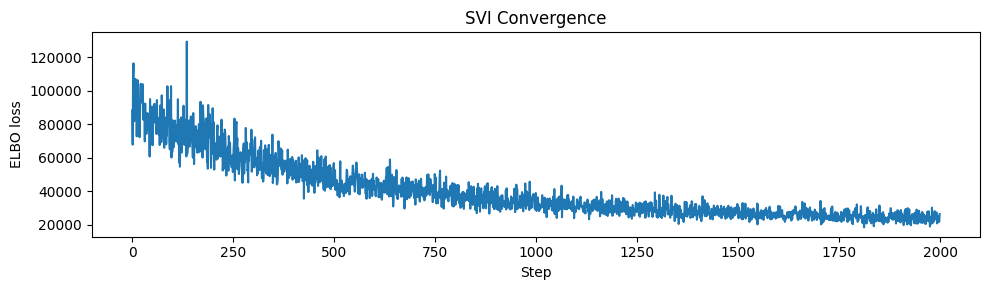

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('ELBO loss')
plt.title('SVI Convergence')
plt.tight_layout()
plt.show()

In [45]:
print(appearance_df['weight'].describe())


count    5046.000000
mean        0.131026
std         0.228010
min         0.000231
25%         0.001833
50%         0.015207
75%         0.144858
max         1.000000
Name: weight, dtype: float64


In [46]:
# Fix 1: clip weights from below to prevent variance explosion
appearance_df['weight'] = appearance_df['weight'].clip(lower=0.1)
print(appearance_df['weight'].clip(lower=0.1).describe())

# Fix 2: normalize weights to [0.1, 1.0] range
# so minimum variance is 1x sigma_noise, maximum is 10x

count    5046.000000
mean        0.190401
std         0.198497
min         0.100000
25%         0.100000
50%         0.100000
75%         0.144858
max         1.000000
Name: weight, dtype: float64


In [40]:
# Fix 2: check your prior scales against actual data
print(appearance_df['mean_xrv'].describe())
print(appearance_df['mean_xrv'].std())  # this should inform sigma_noise prior

count    5046.000000
mean       -0.000717
std         0.006053
min        -0.029598
25%        -0.004601
50%        -0.000853
75%         0.003133
max         0.048983
Name: mean_xrv, dtype: float64
0.006053402
